# Example of dataframe import and plotting of SCF* for colocalization experiments

__Steps__:
1. Download zip folder for a given experiment/condition and extract the data. In this example, we will process data from 'CJW7020_Tac1_1.2uM.zip'
2. Import dataframes generated at step 2 using 'import_processing_no_linking_code.py'. Plot SCF.

__Requirements on how to run__:
1. This notebook assumes the Omnipose-processed extracted file data folder, here 'CJW7020_Tac1_1.2uM', lives in the same folder as the notebook

__Code underlying data and figures__:
- Single-cell data in PDMS microwells, strains CJW7020 and CJW7859, to quantify fluor AMP colocalization with RplA-msfGFP (ribosomes) vs HupA-msfGFP (DNA)
- Figure 4C

### 1. Import dataframes with single cell SCF data

Run time: < 10min 

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Sep 27 12:22:30 2023

@author: fragasso
"""
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
import os
from scipy import io
import skimage
import warnings
import re
warnings.filterwarnings('ignore')


'''Global variables'''
fr = 10    # [min] time between frame
px_size = 0.065841  # um/px   (pixel size in alpha scope, 100x)

In [2]:
'''SCF / labelled-AMP-uptake analysis — single local experiment (no linking).'''
import glob

experiment_path = "CJW7020_Tac1_1.2uM"        # extracted archive folder, next to the notebook
exp_name = experiment_path
AMP_name = "Tac1_1.2uM"
conc_fluor = 60               # [nM] labelled-AMP concentration
t_SCF_sampled = 50            # [min] offset time at which to sample the SCF snapshot

# --- load per-position cell_features_df pickles from the local output folder ---
output_path = experiment_path + '/output'
df = pd.DataFrame()
for f in sorted(glob.glob(output_path + '/*cell_features_df*.pkl')):
    sub = pd.read_pickle(f)
    if len(sub):
        df = pd.concat([df, sub])

# --- derived columns ---
df['AMP'] = AMP_name
df['marker'] = 'RplA-GFP'
df['AMP_normalized'] = AMP_name                       # normalize_amp not needed for one AMP
df['time_min'] = df['frame'] * fr
df['time_min_offset'] = df['time_min'] - df['fr_inj'] * fr

# --- SCF snapshot at the sampled offset time (nearest available frame) ---
offsets = np.sort(df['time_min_offset'].unique())
t_pick = offsets[np.argmin(np.abs(offsets - t_SCF_sampled))]
print('Sampling SCF at offset =', t_pick, 'min')
df_SCF = df[df['time_min_offset'] == t_pick].copy()
df_SCF = df_SCF[(df_SCF['mean_fluor1'] > 100) & (df_SCF['mean_fluor2'] > 100)]
df_SCF['label'] = np.where(df_SCF['mean_fluor2'] > 2500, 'perm', 'no_perm')


Sampling SCF at offset = 50 min


RplA n = {'Tac1_1.2uM': 726}


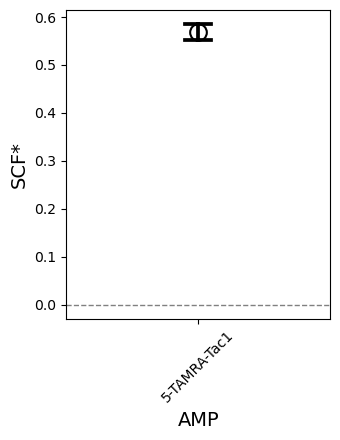

In [3]:
'''Plot SCF'''
AMP_label = '5-TAMRA-Tac1'

# --- SCF point (single AMP) ---
fig = plt.figure(figsize=(3.5, 4.5))
sns.pointplot(
    data=df_SCF.dropna(subset=['SCF']),
    x='AMP_normalized', y='SCF',
    color='black',
    markers='o',
    linestyle='none',                 # seaborn >=0.13: replaces join=False
    capsize=0.1,
    markersize=12, markerfacecolor='none', markeredgewidth=1.5,
)
plt.axhline(0, linewidth=1, linestyle='--', c='grey')
plt.xticks(ticks=[0], labels=[AMP_label], rotation=45)
plt.ylabel('SCF*', fontsize=14)
plt.xlabel('AMP', fontsize=14)
print('RplA n =', df_SCF.groupby('AMP_normalized', observed=True)['cell_id'].nunique().to_dict())
plt.tight_layout()
plt.show()